In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import matplotlib.pyplot as plt
from matplotlib import colors

import sys
sys.path.append("../src")

import netket as nk

from netket.experimental.dynamics import RK45

from callbacks import (
    get_tdvp_monitor_callback,
    get_umbrella_monitor_callback,
)

from logger import Logger

/mnt/home/rwiersema/blurred_sampling/.venv_plot/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: Debug multi-node HPC? `djaxrun -np 2 python Examples/Sharding/multi_process.py`

In [3]:
import jax.numpy as jnp
import numpy as np
import flax.linen as nn

N = 4
hilbert = nk.hilbert.Spin(s=1 / 2, N=N)

def get_vstate(n_samples):
    model = nk.models.RBM(param_dtype=complex, alpha=1)
    sampler = nk.sampler.MetropolisLocal(hilbert, n_chains=n_samples)
    model = nk.models.RBM(
        alpha=1,
        param_dtype=complex,
        use_visible_bias=True,
        hidden_bias_init=nn.initializers.normal(1e-4),
        visible_bias_init=nn.initializers.normal(1e-4),
        kernel_init=nn.initializers.normal(1e-4),
    )
    vstate = nk.vqs.MCState(
        sampler=sampler, model=model, n_samples=n_samples, seed=100, sampler_seed=100
    )
    eps_params = vstate.parameters.copy()
    K = 3
    a = jnp.array([-K]*N, dtype=eps_params['visible_bias'].dtype)
    eps_params["visible_bias"] = a
    vstate.parameters = eps_params.copy()
    
    # Thermalize
    for i in range(100):
        vstate.sample(n_samples=n_samples)
    return vstate


vstate = get_vstate(2**9)
print("Single peak state")
print(vstate.to_array())

Single peak state
[3.77508849e-11-1.72986633e-18j 1.52297925e-08-2.34200470e-16j
 1.52297925e-08-5.61554597e-16j 6.14413676e-06-7.59116770e-15j
 1.52297928e-08+2.17640347e-16j 6.14413679e-06-1.16286597e-13j
 6.14413671e-06+1.05012292e-13j 2.47872182e-03-2.71028976e-11j
 1.52297943e-08-2.80581517e-16j 6.14413654e-06+2.40335140e-13j
 6.14413702e-06-2.12048283e-13j 2.47872158e-03+6.99452117e-11j
 6.14413707e-06+7.06054276e-14j 2.47872158e-03+1.33072784e-11j
 2.47872173e-03-2.66404213e-11j 9.99987712e-01-1.16792283e-08j]


In [4]:
graph = nk.graph.Chain(N, pbc=True)
hamiltonian = nk.operator.IsingJax(hilbert=hilbert, graph=graph, h=1., J=-1.)
n_samples_list = [2**i for i in range(9,15)]

for i in range(N):
    string = ["I"]*N
    string[i] = "Z"
    if i==0:
        sigma_zs=nk.operator.PauliStringsJax(hilbert, "".join(string), 1./N)
    else:
        sigma_zs+=nk.operator.PauliStringsJax(hilbert, "".join(string), 1./N)
fields_to_track = (
    ("t", "values"),
    ("dt", "values"),
    ("Generator", "Mean"),
    ("Generator", "Variance"),
    ("sigma_z", "Mean"),
    ("sigma_z", "Variance"),
    ("r_squared", "values"),
    # Umbrella/bridge monitoring fields
    ("ess_bridge", "values"),
    ("snr_min", "values"),
    ("snr_10p", "values"),
    ("snr_med", "values"),
    ("snrF_min", "values"),
    ("snrF_med", "values"),
    ("q_bridge", "values"),
    # Per-step SNRs from OVar
    ("snr", "values"),
    ("snr_F", "values"),
)


def measure_sigma_z(step, log, driver):
    log['sigma_z'] = driver.state.expect(sigma_zs)
    return True

# Exact dynamics

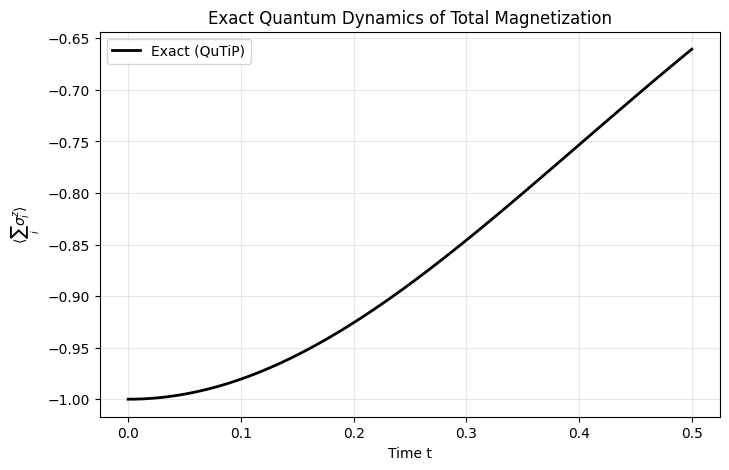

Initial magnetization: -0.999988
Final magnetization: -0.660618


In [5]:
import qutip as qt

# Get the Hamiltonian matrix from netket
H_matrix = hamiltonian.to_sparse()

# Convert to QuTiP Qobj
H_qutip = qt.Qobj(H_matrix)

# Get initial state from vstate
psi0_array = vstate.to_array()
psi0_qutip = qt.Qobj(psi0_array)
psi0_qutip = psi0_qutip.unit()  # Normalize

# Create total magnetization operator (sum of Z_i)
# Convert netket operator to matrix
sigma_z_matrix = sigma_zs.to_sparse() * N  # Multiply by N since sigma_zs is normalized by 1/N

# Convert to QuTiP
Z_total_qutip = qt.Qobj(sigma_z_matrix)

# Time evolution parameters
T = 0.5
times_exact = np.linspace(0.0, T, 100)

# Evolve the state and calculate expectation values
magnetizations_exact = []
for t in times_exact:
    # Evolve state
    psi_t = (-1j * H_qutip * t).expm() * psi0_qutip
    # Calculate expectation value
    mag = qt.expect(Z_total_qutip, psi_t)
    magnetizations_exact.append(mag / 4)

# Plot the exact dynamics
plt.figure(figsize=(8, 5))
plt.plot(times_exact, np.real(magnetizations_exact), 'k-', linewidth=2, label='Exact (QuTiP)')
plt.xlabel('Time t')
plt.ylabel(r'$\langle \sum_i \sigma^z_i \rangle$')
plt.title('Exact Quantum Dynamics of Total Magnetization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Initial magnetization: {np.real(magnetizations_exact[0]):.6f}")
print(f"Final magnetization: {np.real(magnetizations_exact[-1]):.6f}")

## Dynamics

In [6]:
from schmitt_tdvp import TDVPSchmitt
from schmitt_tdvp_randomized_blur import TDVPSchmittRandomizedBlur
from schmitt_tdvp_blur import TDVPSchmittBlur

def fit(flip_prob, n_samples_tvmc):    
    T = 0.5
    save_times = np.linspace(0.0, T, 20)
    exp_name = f"{n_samples_tvmc}_{flip_prob:1.2f}"
    # Make sure we always start with the same state in notebook
    
    save_path = f"./data/TFIM_EPS_{N}/{exp_name}/"
    logger = Logger(path=save_path, fields=fields_to_track)
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    
    vstate = get_vstate(n_samples_tvmc)
    print(vstate.expect(sigma_zs))
    callbacks = []
    callbacks.append(measure_sigma_z)
    tdvp_monitor_callback = get_tdvp_monitor_callback(save_times, save_path)
    callbacks.append(tdvp_monitor_callback)
    integrator = RK45(1e-3)
    tvmc_kwargs = {}
    if flip_prob==0:
        driver = TDVPSchmitt(
            hamiltonian,
            vstate,
            integrator,
            t0=0,
            holomorphic=False,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            **tvmc_kwargs,
        )
    else:
        driver = TDVPSchmittBlur(
        hamiltonian,
        vstate,
        integrator,
        t0=0,
        q=flip_prob,
        holomorphic=False,
        snr_atol=2,
        rcond=1e-14,
        rcond_smooth=1e-10,
            **tvmc_kwargs,
        )
    driver.run(
        T,
        out=logger,
        callback = callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)

In [7]:
for n_samples_tvmc in n_samples_list:
    fit(0.0, n_samples_tvmc)
    fit(0.1, n_samples_tvmc)


Data exists, skipping...
Data exists, skipping...
Data exists, skipping...
Data exists, skipping...
Data exists, skipping...
Data exists, skipping...
Data exists, skipping...
Data exists, skipping...
Data exists, skipping...
Data exists, skipping...
Data exists, skipping...
Data exists, skipping...


Restored Vanilla: True
Restored Blur: True
Restored Vanilla: True
Restored Blur: True
Restored Vanilla: True
Restored Blur: True
Restored Vanilla: True
Restored Blur: True
Restored Vanilla: True
Restored Blur: True
Restored Vanilla: True
Restored Blur: True


/mnt/home/rwiersema/blurred_sampling/.venv_plot/lib/python3.11/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/rwiersema/blurred_sampling/.venv_plot/lib/python3.11/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


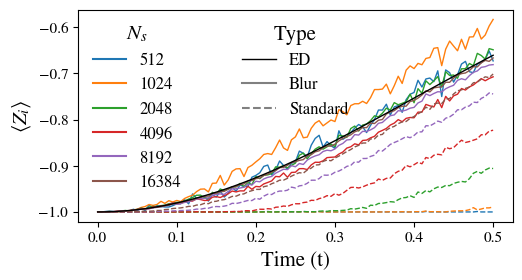

In [9]:
import matplotlib
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"
import matplotlib.lines as mlines
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(5.8, 5.5/2))
gs = GridSpec(1, 1, figure=fig, wspace=0.45, hspace=0.33)
ax_z = fig.add_subplot(gs[0])
fig.subplots_adjust(left=0.15)

color_map = plt.get_cmap('tab10')
ns_handles = []
for idx, n_samples in enumerate(n_samples_list):
    color = color_map(idx % 10)
    # Vanilla (flip_prob=0.0)
    exp_name_vanilla = f"{n_samples}_0.00"
    save_path_vanilla = f"./data/TFIM_EPS_{N}/{exp_name_vanilla}/"
    logger_vanilla = Logger(path=save_path_vanilla, fields=fields_to_track)
    print("Restored Vanilla:", logger_vanilla.restore())
    ax_z.plot(logger_vanilla.data["t"]["values"][::5], logger_vanilla.data["sigma_z"]["Mean"][::5], color=color, linestyle='--', lw=1)
    # Blur (flip_prob=0.1)
    exp_name_blur = f"{n_samples}_0.10"
    save_path_blur = f"./data/TFIM_EPS_{N}/{exp_name_blur}/"
    logger_blur = Logger(path=save_path_blur, fields=fields_to_track)
    print("Restored Blur:", logger_blur.restore())
    ax_z.plot(logger_blur.data["t"]["values"][::5], logger_blur.data["sigma_z"]["Mean"][::5], color=color, linestyle='-',lw=1)
    ns_handles.append(mlines.Line2D([], [], color=color, linestyle='-', label=f'{n_samples}'))
ax_z.set_xlabel("Time (t)", fontsize=15)
ax_z.set_ylabel(r"$\langle Z_i \rangle$", fontsize=15)
ed_handle = mlines.Line2D([], [], color='k', linestyle='-', linewidth=1, label='ED')
vanilla_handle = mlines.Line2D([], [], color='gray', linestyle='-', label='Blur')
blur_handle = mlines.Line2D([], [], color='gray', linestyle='--', label='Standard')
ax_z.plot(times_exact, np.real(magnetizations_exact), 'k-', linewidth=1)
# Place the ED, Vanilla, Blur legend
first_legend = ax_z.legend(handles=[ed_handle, vanilla_handle, blur_handle], loc='upper center', fontsize=12, frameon=False, title='Type', title_fontsize=15)
ax_z.add_artist(first_legend)
ax_z.tick_params(labelsize=11)
loc_x = -0.18
loc_y = 0.95
# ax_z.annotate("(b)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=16)
# Place the Ns legend separately
ax_z.legend(handles=ns_handles, loc='upper left', fontsize=12, frameon=False, title='$N_s$', title_fontsize=15)
fig.savefig("Fig6.pdf",bbox_inches="tight", pad_inches=0.01)